# Photovoltaic Figure of Merit

#### Pre-requisites:
* Structural Relaxation
* Optics
* Band Structure
* DOS Effective Mass

The final figure of merit requires a number of input parameters. Some can be determined from the given light spectrum, some come from the DFT calculations that `solphin` wraps, and some are left as user-specified inputs.


**From Optics:**
* High-frequency dielectric constant (unitless)

**From Band Structure:**
* Band gap (eV)

**From DOS**
* DOS effective mass (mₑ)

**From a spectrum:**
* Photon spectrum (eV vs m⁻² s⁻¹ eV⁻¹)
* Spectral average (cm⁻¹)
* Spectral dispersion (unitless)

**Supplied by user:**
* Dopant density/concentration (cm⁻³)
* Carrier lifetime (s)
* Carrier mobility (cm²V⁻¹s⁻¹)
* Operating temperature (K)

Import the necessary libraries

In [1]:
import solphin.band_structure as band_structure
import solphin.dos as dos
import solphin.final_results as final_results
import solphin.spectral as spectral
import solphin.db_fom as db_fom
import solphin.optics as optics

%load_ext autoreload
%autoreload 2

## Assemble Input Values

Here we load values from previous calculations and process the photon spectrum.

### Optics

The equivalent CASTEP file is `*_epsilon.dat`.

In [2]:
eps_inf, eps_inf_tensor, _, _, _ = optics.calc_dielectric(filename="../tests/data/Cu2GeS3/OPT_hybrid/vasprun.xml", code="vasp")
print(f"Loaded ε∞ of {eps_inf:.2f}")

Loaded ε∞ of 6.11


### DOS Effective Mass

The equivalent CASTEP file is `*.bands`.

In [ ]:
eff_mass = dos.compute_dos(filepath=f"../tests/data/Cu2GeS3/DOS_HDFT/vasprun.xml", code="vasp").final_result
print(f"Loaded DOS effective mass of {eff_mass:.2f} mₑ")

  Computing electron FOM DOS effective mass...
  Computing hole FOM DOS effective mass...
Loaded DOS effective mass of 0.33 mₑ


### Band Structure

In [4]:
bs = band_structure.get_band_structure(band_directory="../tests/data/Cu2GeS3/BAND_SP_HDFT", splits=7)
E_gap_direct = bs.get_direct_band_gap()

print(f"Loaded band gap of {E_gap_direct:.2f} eV")

Loaded band gap of 1.39 eV


### Photon Spectrum

In [5]:
spectrum = db_fom.load_spectrum(spectrum_type="AM1.5")
photon_spectrum = photon_spectrum = db_fom.convert_spectrum(spectrum)
spectral_average, spectral_dispersion = spectral.generate_spectral_parameters(optics_directory="../tests/data/Cu2GeS3/OPT_hybrid", spectrum=spectrum, E_gap=E_gap_direct)

print(f"Spectral Average = {spectral_average:.2f} cm⁻¹")
print(f"Spectral Dispersion = {spectral_dispersion:.2f}")

Spectral Average = 67574.17 cm⁻¹
Spectral Dispersion = 1.18


## Calculate FOM

With all the values loaded, we can calculate the PV Figure of Merit!

1) Specify the user-supplied values.

In [6]:
tau = 1e-6 # s
mu = 1e6 # cm²V⁻¹s⁻¹
doping_density = 1e10 # cm⁻³

Tcell = 300 # K

2) Calculate the FOM.

In [7]:
sq, fom_sq, eff = final_results.SQ_relative_FOM_PV_efficiency(
    E_gap = E_gap_direct,
    photon_spectrum = photon_spectrum, 
    alpha = spectral_average, 
    tau = tau,
    sigma = spectral_dispersion, 
    dos_mass = eff_mass, 
    dop_density = doping_density, 
    epsilon = eps_inf,
    mu = mu, 
    Tcell = Tcell,
    )

print(f"Photovoltaic Figure of Merit total efficiency: {eff:.2f} %")
print(f"SQ limit: {sq:.2f} %")
print(f"Photovoltaic Figure of Merit relative to the SQ limit: {fom_sq:.2f} %")

Photovoltaic Figure of Merit total efficiency: 22.65 %
SQ limit: 33.51 %
Photovoltaic Figure of Merit relative to the SQ limit: 67.59 %


**OR** Interactively investigate the effect of the user-supplied parameters. This requires the `ipywidgets` package to be set up in your notebook.

In [9]:
final_results.print_final_result_interactive(E_gap_direct, photon_spectrum, spectral_average, tau, spectral_dispersion,
                                             eff_mass, doping_density, eps_inf, mu, Tcell)

interactive(children=(FloatLogSlider(value=10000000000.0, description='Doping Density (cm⁻³)', layout=Layout(w…

interactive(children=(FloatLogSlider(value=10000000000.0, description='Doping Density (cm⁻³)', layout=Layout(w…

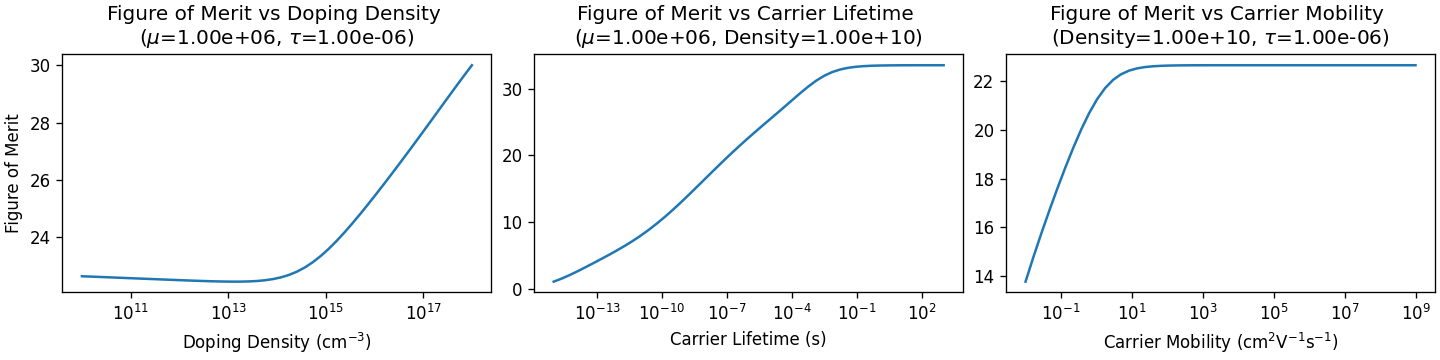

In [10]:
%matplotlib widget
final_results.plot_final_result_interactive(E_gap_direct, photon_spectrum, spectral_average, tau, spectral_dispersion,
                                            eff_mass, doping_density, eps_inf, mu, Tcell)